In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(
    context="talk",
    style="whitegrid",
    palette="deep",
    font_scale=1.0,
 )
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 14,
    "lines.linewidth": 2.2,
    "lines.markersize": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
})

%config InlineBackend.figure_format = 'retina'

native_df = pd.read_csv('output_files/native/native.csv')
decoys_df = pd.read_csv('output_files/decoys/decoys.csv')
all_native_df = pd.read_csv('output_files/native/all_native.csv')

def add_ring_mean_columns(df, radius_col='radius', n_rings=10):
    for ring_id in range(1, n_rings + 1):
        # Valore medio del raggio dell'anello in Angstrom
        df[f'ring{ring_id}_mean_A'] = df[radius_col] * (ring_id - 0.5) / 10
    return df

native_df = add_ring_mean_columns(native_df)
decoys_df = add_ring_mean_columns(decoys_df)
all_native_df = add_ring_mean_columns(all_native_df)

native_labeled = native_df.copy()
native_labeled['dataset_label'] = 'native'

decoys_labeled = decoys_df.copy()
decoys_labeled['complex_name'] = decoys_labeled['complex_name'].astype(str).str.split('-').str[0].str[:4]
decoys_labeled['dataset_label'] = 'decoy'

tot_df = pd.concat([native_labeled, decoys_labeled], ignore_index=True)

rings = [f'ring{n}_mean_A' for n in range(1, 11)]
zernike = [f'zernike_ring{n}_mean' for n in range(1, 11)]
zernike_sigma = [f'zernike_ring{n}_uncertainty' for n in range(1, 11)]
physical = [f'physical_ring{n}_mean' for n in range(1, 11)]
physical_sigma = [f'physical_ring{n}_uncertainty' for n in range(1, 11)]
roughness = [f'roughness_ring{n}' for n in range(1, 11)]

print('native_df:', native_df.shape)
print('decoys_df:', decoys_df.shape)
print('all_native_df:', all_native_df.shape)
print('tot_df:', tot_df.shape)


native_df: (3134, 73)
decoys_df: (3134, 73)
all_native_df: (3731, 73)
tot_df: (6268, 74)


# Complesso 1A1U: Piano di complementarità

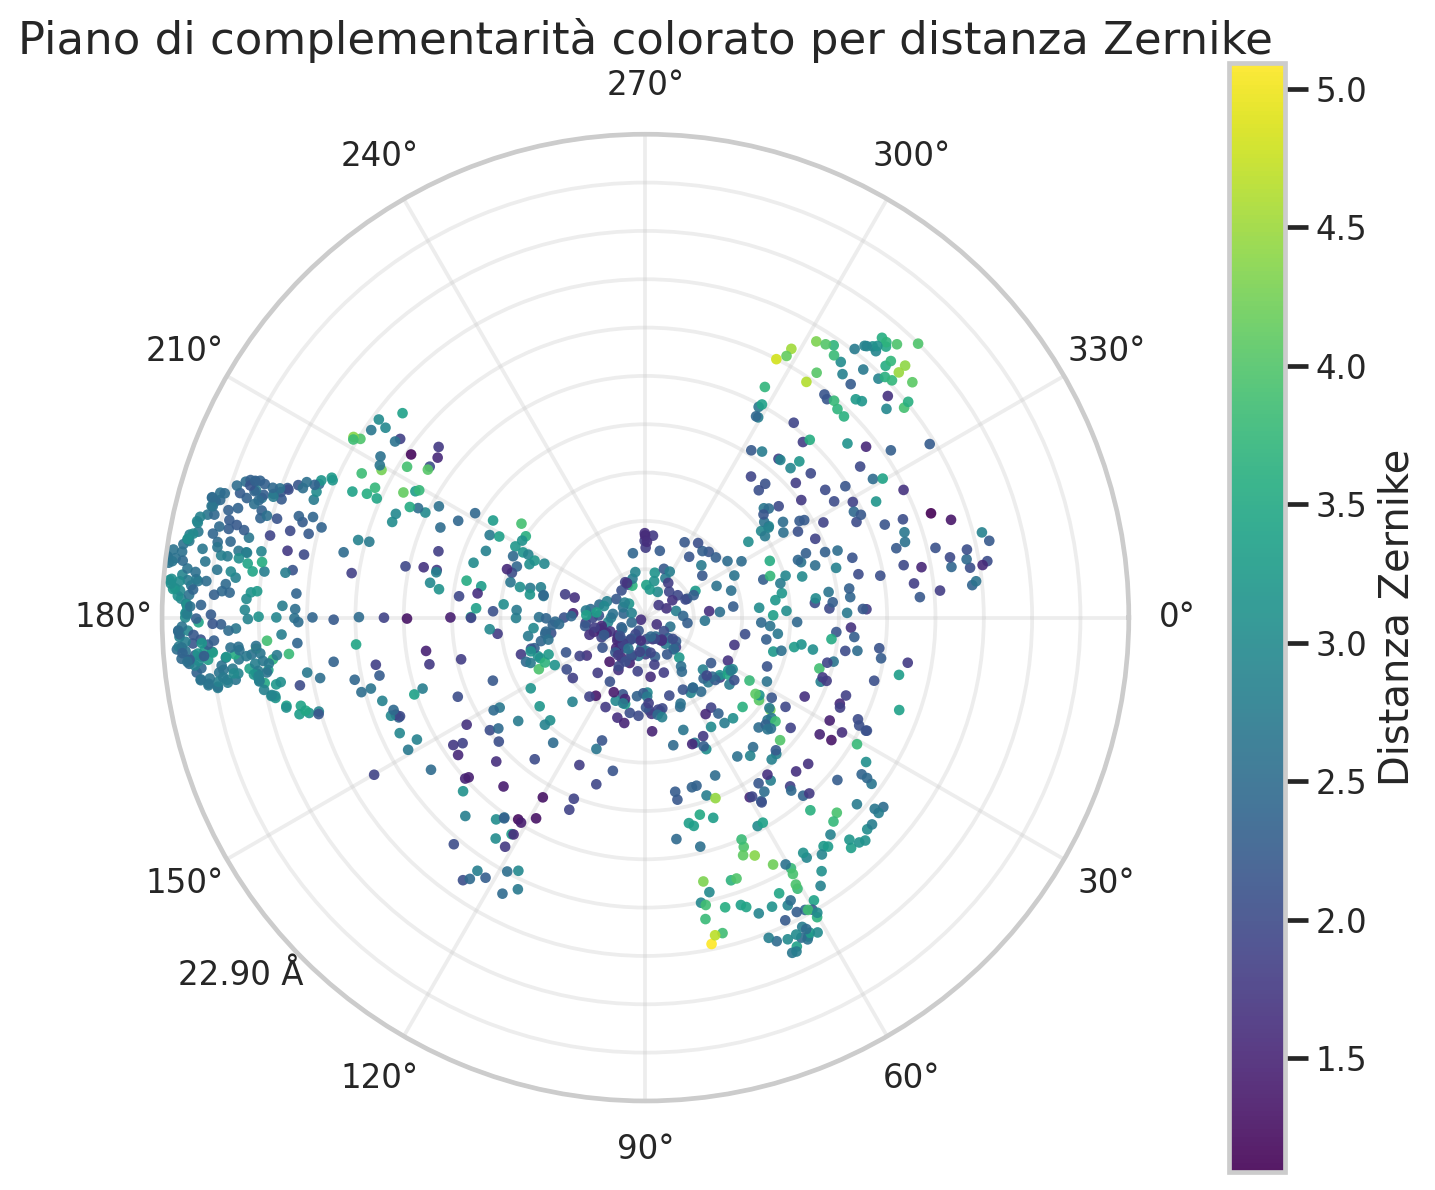

In [9]:
from pathlib import Path
from io import BytesIO
from IPython.display import display, Image

csv_path = Path('output_files/1a1u/1a1u_A_1a1u_C_complementary_plane.csv')

plane_meta = {}
with csv_path.open() as handle:
    for line in handle:
        if not line.startswith('#'):
            break
        key, value = line[1:].split(':', 1)
        plane_meta[key.strip()] = [float(item) for item in value.strip().split(',')]

df_plane = pd.read_csv(csv_path, comment='#')

phys_col = 'physical_distance'
zernike_col = 'zernike_distance'
center_uv = np.array(plane_meta['center_u,center_v'], dtype=float)
circle_radius = float(plane_meta['circle_radius'][0])

dfp = df_plane.dropna(subset=[phys_col, zernike_col]).reset_index(drop=True)

if 'theta' in dfp.columns and 'radial_distance' in dfp.columns:
    theta = dfp['theta'].to_numpy(dtype=float)
    radial = dfp['radial_distance'].to_numpy(dtype=float)
else:
    if {'plane_u', 'plane_v'}.issubset(dfp.columns):
        plane_u = dfp['plane_u'].to_numpy(dtype=float)
        plane_v = dfp['plane_v'].to_numpy(dtype=float)
    else:
        plane_u = dfp['plane_u1'].to_numpy(dtype=float)
        plane_v = dfp['plane_v1'].to_numpy(dtype=float)

    theta = np.arctan2(plane_v - center_uv[1], plane_u - center_uv[0])
    radial = np.hypot(plane_u - center_uv[0], plane_v - center_uv[1])

fig, ax = plt.subplots(1, 1, figsize=(9, 8), subplot_kw={'projection': 'polar'})
ring_ticks = np.linspace(circle_radius / 10.0, circle_radius, 10)
theta_labels = [f'{deg}°' for deg in range(0, 360, 30)]
radial_labels = [''] * (len(ring_ticks) - 1) + [f'{circle_radius:.2f} Å']

ax.set_theta_zero_location('E')
ax.set_theta_direction(-1)
ax.set_rlim(0, circle_radius)
ax.set_rticks(ring_ticks)
ax.set_yticklabels(radial_labels)
for label in ax.get_yticklabels():
    label.set_horizontalalignment('right')
    label.set_verticalalignment('top')
ax.set_thetagrids(np.arange(0, 360, 30), labels=theta_labels)
ax.grid(True, alpha=0.35)
ax.set_rlabel_position(135)

sc = ax.scatter(theta, radial, c=dfp[zernike_col], cmap='viridis', s=18, alpha=0.9, edgecolors='none')
ax.set_title('Piano di complementarità colorato per distanza Zernike')

cbar = fig.colorbar(sc, ax=ax, pad=0.08)
cbar.set_label('Distanza Zernike')

buffer = BytesIO()
fig.savefig(buffer, format='png', dpi=180, bbox_inches='tight')
buffer.seek(0)
display(Image(data=buffer.getvalue()))
out_dir = Path('relazione')
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig('presentation/fig01_1a1u_complementary_plane.pdf', dpi=180, bbox_inches='tight')
plt.close(fig)